# Project B: Algorithmic Trading Strategy Simulation (15.458)

**Objective**: Implement, backtest, and analyze a contrarian long/short equity strategy using CRSP data.

## Data Requirements
- **Source**: SQL (crispy09 @ hedge.mit.edu) or CSV export
- **Universe**: Equities with `project b = 1` in dim_equity
- **In-sample**: 1/1/1992 to 12/31/1997
- **Out-of-sample (Part 4)**: 1998-2000, 2001-2003
- **Returns**: Log returns (continuously compounded), 252 trading days/year

In [89]:
# ========== Section 0: Setup and Data Loading ==========
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
# for 1(f) ACF: pip install statsmodels

# Constants
TRADING_DAYS = 252
SIM_START = '1992-01-01'
SIM_END = '1997-12-31'
OOS1_START, OOS1_END = '1998-01-01', '2000-12-31'
OOS2_START, OOS2_END = '2001-01-01', '2003-12-31'
pid = '924904750'  # Kerberos ID

In [43]:
# Load data. Extended file includes OOS periods (1998-2003).
# Columns needed: date (d), stock id (id), return (ret)
DATA_PATH = 'full_legit_please_work.csv'

# CSV has: double-quoted fields, CRLF line endings, scientific notation in ret,
# empty strings in p_open/p_high/p_low (treated as NA). UTF-8 encoding.
df = pd.read_csv(
    DATA_PATH,
    encoding='utf-8',
    quotechar='"',
    doublequote=True,
    low_memory=False,  # avoid mixed-type warnings on large file
)
# Parse date and ensure correct dtypes
df['d'] = pd.to_datetime(df['d'])
df['id'] = df['id'].astype(int)
df['ret'] = pd.to_numeric(df['ret'], errors='coerce')
df = df.sort_values(['d', 'id']).reset_index(drop=True)

# Pivot to wide format: rows = dates, columns = stock ids
ret_wide = df.pivot(index='d', columns='id', values='ret')

# For lag strategies, ensure we have enough history (e.g., k=5 needs 5 days before SIM_START)
ret_wide = ret_wide.dropna(how='all')
print(f"Returns matrix shape: {ret_wide.shape}")
print(f"Date range: {ret_wide.index.min()} to {ret_wide.index.max()}")

Returns matrix shape: (3032, 690)
Date range: 1991-12-23 00:00:00 to 2003-12-31 00:00:00


---
## Part 0: Data quality checks

In [44]:
# 1. Duplicate rows: same (date, id) appearing more than once
dup_check = df.duplicated(subset=['d', 'id']).sum()
print("1. DUPLICATE ROWS (date, id):")
print(f"   Duplicate (d, id) pairs: {dup_check}")
if dup_check > 0:
    print(f"   Sample duplicates:\n{df[df.duplicated(subset=['d', 'id'], keep=False)].head(10)}")

1. DUPLICATE ROWS (date, id):
   Duplicate (d, id) pairs: 0


In [45]:
# 2. Date coverage: stocks per day (look for sudden drops/spikes)
stocks_per_day = ret_wide.notna().sum(axis=1)
print("2. DATE COVERAGE (stocks per day):")
print(f"   Min stocks/day: {stocks_per_day.min()}, Max: {stocks_per_day.max()}, Mean: {stocks_per_day.mean():.0f}")
if (stocks_per_day.diff().abs() > 100).any():
    spike_days = stocks_per_day.diff().abs()[stocks_per_day.diff().abs() > 100]
    print(f"   Days with >100 stock change: {len(spike_days)}")

2. DATE COVERAGE (stocks per day):
   Min stocks/day: 631, Max: 690, Mean: 684


In [46]:
# 3. Return bounds (log returns: flag extreme values)
ret_flat = ret_wide.values.flatten()
ret_valid = ret_flat[~np.isnan(ret_flat)]
impossible = (ret_valid < -1).sum()  # < -100% impossible for simple; suspicious for log
extreme = ((ret_valid > 0.5) | (ret_valid < -0.5)).sum()
print("3. RETURN BOUNDS:")
print(f"   Returns < -1 (impossible): {impossible}")
print(f"   Returns outside ±50% (extreme, flag for review): {extreme}")

3. RETURN BOUNDS:
   Returns < -1 (impossible): 5
   Returns outside ±50% (extreme, flag for review): 95


In [47]:
# 4. Zero returns: stocks with many consecutive zeros (possible stale data)
valid_count = ret_wide.notna().sum(axis=0)
zero_count = (ret_wide == 0).sum(axis=0)
zero_pct = zero_count / valid_count.replace(0, np.nan)
high_zero_stocks = (zero_pct > 0.5).fillna(False).sum()
print("4. ZERO RETURNS (potential stale data):")
print(f"   Stocks with >50% zero returns: {int(high_zero_stocks)}")

4. ZERO RETURNS (potential stale data):
   Stocks with >50% zero returns: 0


In [48]:
# 6. NaN summary by column and by date
print("6. NaN SUMMARY:")
print(f"   Total NaN in ret_wide: {ret_wide.isna().sum().sum()}")
print(f"   NaN by date (max): {ret_wide.isna().sum(axis=1).max()} per day")

6. NaN SUMMARY:
   Total NaN in ret_wide: 17775
   NaN by date (max): 59 per day


In [49]:
# 7. Volume consistency (if available)
if 'volume' in df.columns:
    zero_vol_nonzero_ret = ((df['volume'] == 0) | (df['volume'].isna())) & (df['ret'].notna()) & (df['ret'] != 0)
    print("7. VOLUME CONSISTENCY:")
    print(f"   Rows with zero/missing volume but non-zero return: {zero_vol_nonzero_ret.sum()}")
else:
    print("7. VOLUME CONSISTENCY: (volume column not in df, skipping)")

7. VOLUME CONSISTENCY:
   Rows with zero/missing volume but non-zero return: 36542


In [50]:
# 8. Price validity (if available)
if 'p' in df.columns:
    bad_price = (df['p'] <= 0) | (df['p'].isna())
    print("8. PRICE VALIDITY:")
    print(f"   Rows with non-positive or missing price: {bad_price.sum()}")
else:
    print("8. PRICE VALIDITY: (p column not in df, skipping)")

8. PRICE VALIDITY:
   Rows with non-positive or missing price: 17775


In [51]:
# 9. Cross-sectional dispersion: unusually high/low variance days
daily_std = ret_wide.std(axis=1)
print("9. CROSS-SECTIONAL DISPERSION:")
print(f"   Daily return std: min={daily_std.min():.4f}, max={daily_std.max():.4f}, median={daily_std.median():.4f}")
extreme_std_days = daily_std[daily_std > daily_std.quantile(0.99)]
print(f"   Days in top 1% dispersion: {len(extreme_std_days)}")

9. CROSS-SECTIONAL DISPERSION:
   Daily return std: min=0.0149, max=0.0819, median=0.0254
   Days in top 1% dispersion: 31


### Data Cleaning and Fixes

Apply corrections based on quality checks. Cleaned data used for strategy.

In [52]:
# Create cleaned copy; apply fixes before pivot
df_clean = df.copy()

# Fix 1: Drop duplicate (d, id) - keep first occurrence
df_clean = df_clean.drop_duplicates(subset=['d', 'id'], keep='first')

# Fix 2: Replace impossible returns (ret < -1) with NaN
# Log returns < -1 imply >63% loss in one day - data error for CRSP
df_clean.loc[df_clean['ret'] < -1, 'ret'] = np.nan

# Fix 3: Winsorize extreme returns at ±50% (optional, reduces outlier impact)
# Log return ±0.5 ≈ ±65% simple return - cap for robustness
df_clean['ret'] = df_clean['ret'].clip(lower=-0.5, upper=0.5)

# Rebuild ret_wide from cleaned df
ret_wide = df_clean.pivot(index='d', columns='id', values='ret')

print(f"Cleaned: {len(df) - len(df_clean)} duplicates dropped")
print(f"Returns matrix shape: {ret_wide.shape}")

Cleaned: 0 duplicates dropped
Returns matrix shape: (3032, 690)


---
## Part 1: Strategy Simulation

**Formulas:**
- Market return: $R(t) = \frac{1}{N}\sum_i R_i(t)$
- Raw weights: $w_i^{raw}(t) \propto -(R_i(t) - R(t))$
- Normalization (Eq. 4): $\sum_{i \in L} w_i = 1$, $\sum_{j \in S} |w_j| = 1$
- Portfolio return: $\pi(t) = \sum_i w_i(t-1) R_i(t)$

In [53]:
def compute_market_return(ret_df):
    """R(t) = equal-weighted average of all stocks"""
    return ret_df.mean(axis=1)

def compute_raw_weights(excess_returns):
    """w_i raw ∝ -(R_i - R). Returns DataFrame same shape as excess_returns."""
    return -excess_returns

def normalize_weights_long_short(w_raw):
    """
    Scale so sum(long) = 1 and sum(abs(short)) = 1.
    w_raw: Series or row of excess returns (positive = long, negative = short)
    """
    w = w_raw.copy()
    longs = w > 0
    shorts = w < 0
    if longs.sum() > 0:
        w[longs] = w[longs] / w[longs].sum()
    if shorts.sum() > 0:
        w[shorts] = w[shorts] / w[shorts].abs().sum()
    return w

def contrarian_weights_at_t(ret_row, market_ret):
    """Weights for one day: raw then normalized (Eq. 2, 4)."""
    excess = ret_row - market_ret
    w_raw = compute_raw_weights(excess)
    return normalize_weights_long_short(w_raw)

def compute_portfolio_returns(ret_wide, weights_df):
    """π(t) = sum_i w_i(t-1) * R_i(t). Align by shifting weights."""
    # weights_df index = dates when weights are set; ret_wide = next-day returns
    pi = (weights_df.shift(1) * ret_wide).sum(axis=1)
    return pi.dropna()

In [54]:
# Compute strategy: use FULL ret_wide (all data) for correct lag history, write results only for simulation period
# ret_wide has full CSV data (incl. 1991); simulation period = 1992-01-01 to 1997-12-31
mask = (ret_wide.index >= SIM_START) & (ret_wide.index <= SIM_END)
ret_insample = ret_wide.loc[mask].copy()  # simulation period only (for filtering outputs)

R_mkt = compute_market_return(ret_wide)  # full data for lag history
weights_list = []
for t in ret_wide.index:
    w = contrarian_weights_at_t(ret_wide.loc[t], R_mkt.loc[t])
    weights_list.append(w)
weights_k1 = pd.DataFrame(weights_list, index=ret_wide.index, columns=ret_wide.columns)

pi_strategy_full = compute_portfolio_returns(ret_wide, weights_k1)
pi_strategy = pi_strategy_full.loc[(pi_strategy_full.index >= SIM_START) & (pi_strategy_full.index <= SIM_END)]
R_mkt_aligned = R_mkt.loc[pi_strategy.index]

### 1(a) Plot daily portfolio returns π(t) and market returns R(t)

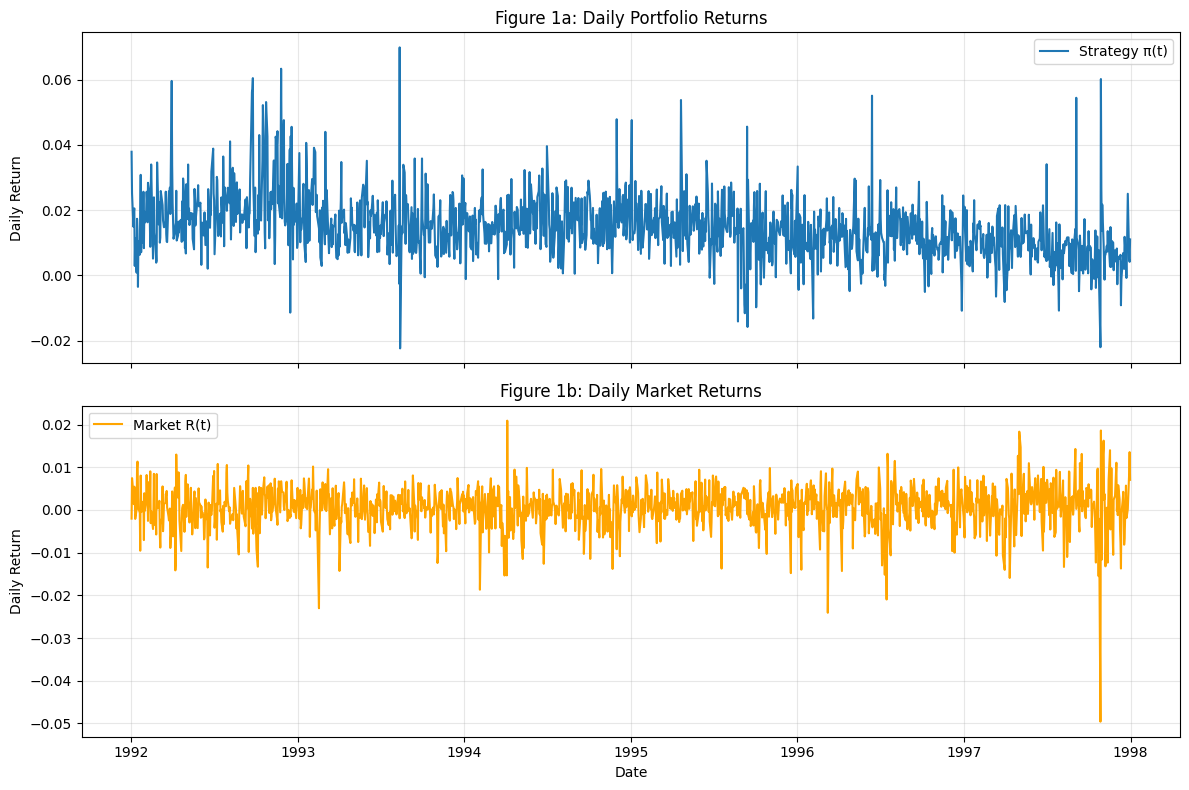

In [55]:
# TODO: Create two labeled plots (or subplots)
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
axes[0].plot(pi_strategy.index, pi_strategy.values, label='Strategy π(t)')
axes[0].set_ylabel('Daily Return')
axes[0].set_title('Figure 1a: Daily Portfolio Returns')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(R_mkt_aligned.index, R_mkt_aligned.values, color='orange', label='Market R(t)')
axes[1].set_ylabel('Daily Return')
axes[1].set_xlabel('Date')
axes[1].set_title('Figure 1b: Daily Market Returns')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 1(b) Annualized mean return, volatility, Sharpe ratio (strategy vs market)

In [56]:
# TODO: Annualize: mean*252, vol*sqrt(252). Sharpe ≈ mean/vol (rf=0). Report 2-3 sigfigs.
def annualize_stats(daily_ret):
    mu = daily_ret.mean() * TRADING_DAYS
    vol = daily_ret.std() * np.sqrt(TRADING_DAYS)
    sharpe = mu / vol if vol > 0 else np.nan
    return mu, vol, sharpe

mu_pi, vol_pi, sharpe_pi = annualize_stats(pi_strategy)
mu_R, vol_R, sharpe_R = annualize_stats(R_mkt_aligned)

print("Strategy:  Mean {:.2%}  Vol {:.2%}  Sharpe {:.2f}".format(mu_pi, vol_pi, sharpe_pi))
print("Market:    Mean {:.2%}  Vol {:.2%}  Sharpe {:.2f}".format(mu_R, vol_R, sharpe_R))

Strategy:  Mean 372.64%  Vol 15.28%  Sharpe 24.39
Market:    Mean 14.77%  Vol 7.80%  Sharpe 1.89


### 1(c) Consistency over time? Stationarity of strategy returns?

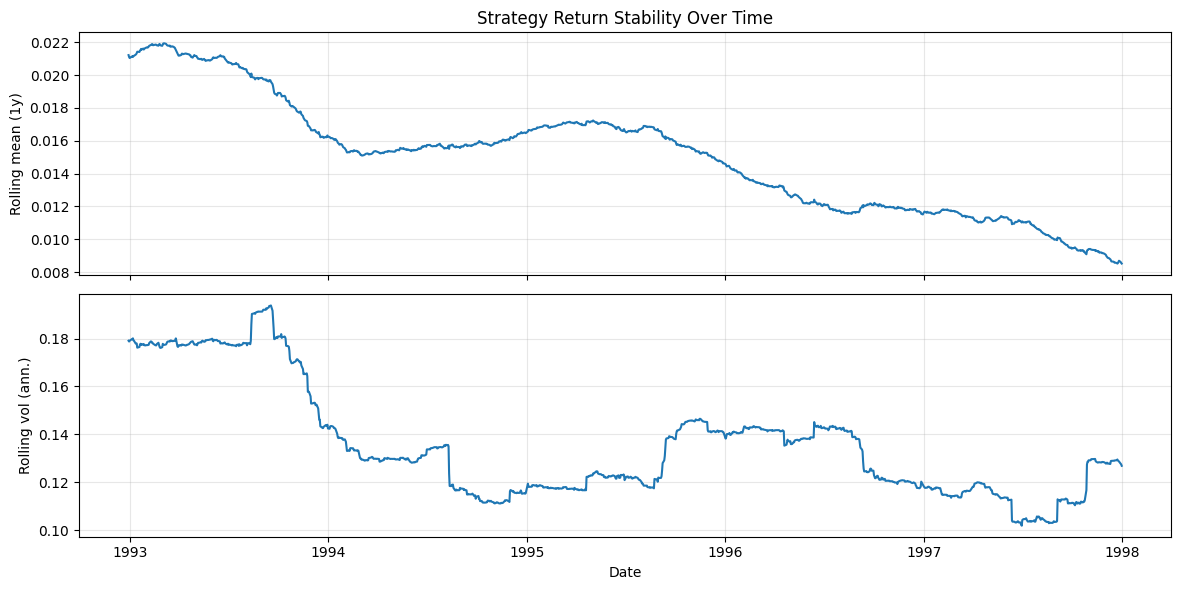

Early half: mean 452.8987%, vol 15.2477%
Late half:  mean 292.3887%, vol 13.5446%


In [57]:
# TODO: Rolling mean/vol, subsample stats, or formal stationarity test
# Hint: Split sample into halves or rolling windows; compare mean/vol
window = 252  # 1 year
rolling_mean = pi_strategy.rolling(window).mean()
rolling_vol = pi_strategy.rolling(window).std() * np.sqrt(TRADING_DAYS)

fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
axes[0].plot(rolling_mean.index, rolling_mean.values)
axes[0].set_ylabel('Rolling mean (1y)')
axes[0].set_title('Strategy Return Stability Over Time')
axes[0].grid(True, alpha=0.3)
axes[1].plot(rolling_vol.index, rolling_vol.values)
axes[1].set_ylabel('Rolling vol (ann.)')
axes[1].set_xlabel('Date')
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Subsample comparison: TODO fill in interpretation
half = len(pi_strategy) // 2
early, late = pi_strategy.iloc[:half], pi_strategy.iloc[half:]
print("Early half: mean {:.4%}, vol {:.4%}".format(early.mean()*252, early.std()*np.sqrt(252)))
print("Late half:  mean {:.4%}, vol {:.4%}".format(late.mean()*252, late.std()*np.sqrt(252)))

### 1(d) Unusual events (days)? Stock outliers? Effect on strategy?

In [58]:
# TODO: Flag unusual days (z-score > 3?), stock-level outliers, robustness check
z_scores = np.abs(stats.zscore(pi_strategy.dropna()))
unusual_days = pi_strategy.index[z_scores > 3]
print("Unusual strategy return days (|z|>3):", list(unusual_days) if len(unusual_days) else "None")

# Stock-level: which stocks have extreme returns most often?
# TODO: Define outlier threshold per stock; identify problematic stocks
# TODO: Re-run strategy excluding outliers; compare metrics

Unusual strategy return days (|z|>3): [Timestamp('1992-03-30 00:00:00'), Timestamp('1992-09-21 00:00:00'), Timestamp('1992-09-22 00:00:00'), Timestamp('1992-09-23 00:00:00'), Timestamp('1992-09-24 00:00:00'), Timestamp('1992-10-16 00:00:00'), Timestamp('1992-10-23 00:00:00'), Timestamp('1992-11-17 00:00:00'), Timestamp('1992-11-25 00:00:00'), Timestamp('1992-12-01 00:00:00'), Timestamp('1992-12-18 00:00:00'), Timestamp('1993-03-02 00:00:00'), Timestamp('1993-08-12 00:00:00'), Timestamp('1993-08-13 00:00:00'), Timestamp('1994-12-01 00:00:00'), Timestamp('1995-01-03 00:00:00'), Timestamp('1995-04-21 00:00:00'), Timestamp('1995-08-24 00:00:00'), Timestamp('1995-09-13 00:00:00'), Timestamp('1995-09-14 00:00:00'), Timestamp('1996-06-13 00:00:00'), Timestamp('1997-09-04 00:00:00'), Timestamp('1997-10-27 00:00:00'), Timestamp('1997-10-28 00:00:00')]


### 1(e) Correlation between strategy and market. Market-neutral or dollar-neutral?

In [59]:
# TODO: Compute correlation; interpret
corr = np.corrcoef(pi_strategy.dropna(), R_mkt_aligned.reindex(pi_strategy.index).dropna())[0, 1]
print("Correlation(π, R_market) = {:.4f}".format(corr))
# Dollar-neutral: long+short weights sum to 0. Market-neutral: low correlation with market.

Correlation(π, R_market) = 0.0550


### 1(f) Autocorrelation of strategy returns?

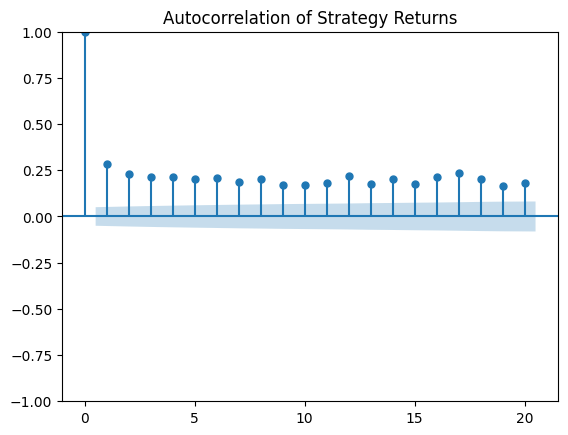

In [60]:
# TODO: ACF plot; interpret (e.g., momentum vs mean-reversion implications)
from statsmodels.graphics.tsaplots import plot_acf
plot_acf(pi_strategy.dropna(), lags=20)
plt.title('Autocorrelation of Strategy Returns')
plt.show()

### 1(g) Maximum drawdown (peak-to-trough decline in cumulative return)

In [61]:
# TODO: Cumulative return, then max drawdown = max(peak - trough) over running peak
cumret = (1 + pi_strategy).cumprod()
running_max = cumret.expanding().max()
drawdown = (cumret - running_max) / running_max
max_dd = drawdown.min()
print("Maximum drawdown: {:.2%}".format(max_dd))

Maximum drawdown: -2.85%


### 1(h) Correlation between long and short sub-portfolio returns

In [62]:
# Long leg: sum over w>0 of w(t-1)*R(t); short leg: sum over w<0 of w(t-1)*R(t)
w_prev = weights_k1.shift(1)
ret_long = (w_prev.clip(lower=0) * ret_insample).sum(axis=1).dropna()
ret_short = (w_prev.clip(upper=0) * ret_insample).sum(axis=1).dropna()
common_idx = ret_long.index.intersection(ret_short.index)
corr_ls = np.corrcoef(ret_long.loc[common_idx], ret_short.loc[common_idx])[0, 1]
print("Correlation(long leg, short leg) = {:.4f}".format(corr_ls))

Correlation(long leg, short leg) = 0.0512


### 1(i) Realism, implementability, data issues

*Discussion cell. Consider: transaction costs, market impact, slippage, survivorship bias, look-ahead bias, data quality.*

In [63]:
# Sum of all daily returns in Part 1
sum_daily_returns = pi_strategy.sum()
print(f"Sum of all daily returns: {sum_daily_returns:.6f}")

Sum of all daily returns: 22.447346


Alfredo --- Here I was just checking and trying to see what I found.

In [64]:
print("daily mean:", pi_strategy.mean())
print("daily vol:", pi_strategy.std())
print("daily sharpe:", pi_strategy.mean()/pi_strategy.std())

daily mean: 0.01478744804093162
daily vol: 0.009624148480094437
daily sharpe: 1.5364941710444724


In [65]:
weights_k1.loc[pi_strategy.index].apply(lambda r: (r[r>0].sum(), r[r<0].sum()), axis=1).head()

d
1992-01-02    (0.9999999999999998, -0.9999999999999999)
1992-01-03                   (1.0, -0.9999999999999999)
1992-01-06                   (1.0, -1.0000000000000002)
1992-01-07                                  (1.0, -1.0)
1992-01-08    (0.9999999999999999, -0.9999999999999999)
dtype: object

In [66]:
ann_mean = pi_strategy.mean() * 252
ann_vol = pi_strategy.std() * np.sqrt(252)
sharpe = ann_mean / ann_vol
print(sharpe)

24.391088804904083


In [67]:
pi_strategy.describe(percentiles=[.01,.05,.95,.99])

count    1518.000000
mean        0.014787
std         0.009624
min        -0.022348
1%         -0.005023
5%          0.001184
50%         0.013893
95%         0.029272
99%         0.047227
max         0.069856
dtype: float64

In [68]:
print(pi_strategy.std())

0.009624148480094437


In [69]:
print(ret_insample.stack().describe())

count    1.046550e+06
mean     5.861151e-04
std      2.500156e-02
min     -5.000000e-01
25%     -9.302393e-03
50%      0.000000e+00
75%      1.003878e-02
max      5.000000e-01
dtype: float64


In [70]:
R_mkt = compute_market_return(ret_insample)
daily_mean = R_mkt.mean()
daily_vol  = R_mkt.std()
daily_sharpe = daily_mean / daily_vol

ann_mean = daily_mean * 252
ann_vol  = daily_vol * np.sqrt(252)
ann_sharpe = ann_mean / ann_vol

print("Market daily mean:", daily_mean)
print("Market daily vol:", daily_vol)
print("Market daily Sharpe:", daily_sharpe)

print("\nMarket annual mean:", ann_mean)
print("Market annual vol:", ann_vol)
print("Market annual Sharpe:", ann_sharpe)

Market daily mean: 0.0005862338478318489
Market daily vol: 0.0049157932744418225
Market daily Sharpe: 0.11925518733259069

Market annual mean: 0.14773092965362591
Market annual vol: 0.07803579900466169
Market annual Sharpe: 1.8931174094187309


In [71]:
# align weights to strategy dates
w = weights_k1.loc[pi_strategy.index]

# daily turnover
turnover = 0.5 * np.abs(w.diff()).sum(axis=1)

# drop first NaN
turnover = turnover.dropna()

print("Average daily turnover:", turnover.mean())
print("Median daily turnover:", turnover.median())
print("Max daily turnover:", turnover.max())

# annual turnover
print("Annual turnover:", turnover.mean() * 252)

Average daily turnover: 1.5367485809238839
Median daily turnover: 1.5387365338878278
Max daily turnover: 1.7870193105051153
Annual turnover: 387.26064239281874


,half_spread_bps,ann_mean,ann_vol,sharpe,avg_daily_cost,ann_cost_drag
0,0,372.64%,15.28%,24.39,0.000000,0.00%
1,2,357.15%,15.26%,23.41,0.000615,15.49%
2,5,333.92%,15.22%,21.93,0.001537,38.73%
3,10,295.19%,15.17%,19.46,0.003073,77.45%
4,25,179.01%,15.02%,11.92,0.007684,193.63%
5,30,140.29%,14.97%,9.37,0.009220,232.36%
6,40,62.84%,14.87%,4.23,0.012294,309.81%
7,50,-14.62%,14.77%,-0.99,0.015367,387.26%
8,75,-208.25%,14.54%,-14.33,0.023051,580.89%
9,100,-401.88%,14.32%,-28.06,0.030735,774.52%


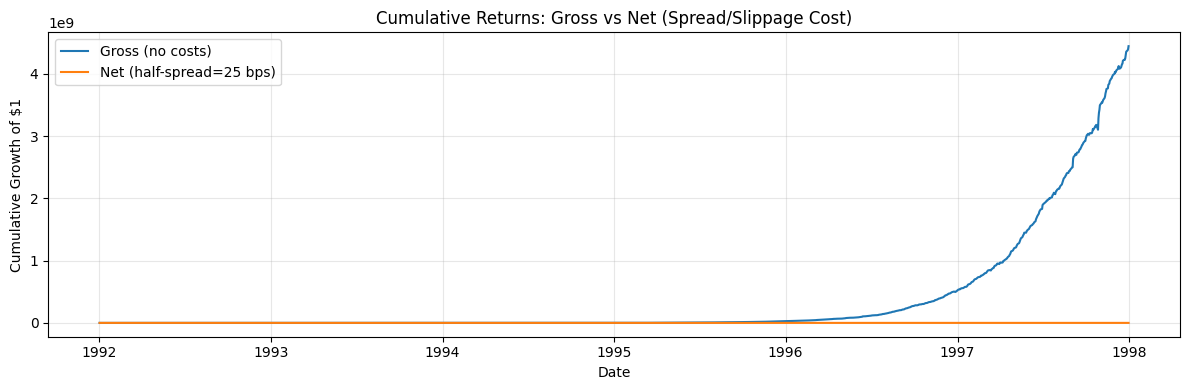

Gross: ann mean=372.64% | ann vol=15.28% | Sharpe=24.39
Net @ 25 bps half-spread: ann mean=179.01% | ann vol=15.02% | Sharpe=11.92
Avg daily two-way traded fraction: 3.073  (your earlier one-way turnover was ~1.537)


In [72]:
pi_gross = pi_strategy.copy()
w = weights_k1.loc[pi_gross.index]

# two-way traded fraction per stock (fraction of PV traded in that name)
dw = w.diff().abs().fillna(0.0)

# total two-way traded fraction each day (this is the key multiplier for spread costs)
two_way_trade = dw.sum(axis=1)

def ann_stats(r):
    r = r.dropna()
    mu = r.mean() * 252
    vol = r.std() * np.sqrt(252)
    sh = mu / vol if vol > 0 else np.nan
    return mu, vol, sh

# ---- Try a spread/slippage grid (bps of HALF-spread / effective cost per $ traded) ----
# You can edit this list. For 1990s, values like 10–50 bps HALF-spread are not crazy,
# depending on liquidity/universe and execution quality.
half_spread_bps_grid = [0, 2, 5, 10, 25, 30, 40, 50, 75, 100]

rows = []
for bps in half_spread_bps_grid:
    c = bps / 10000.0
    cost_t = c * two_way_trade
    pi_net = pi_gross - cost_t

    mu, vol, sh = ann_stats(pi_net)
    rows.append({
        "half_spread_bps": bps,
        "ann_mean": mu,
        "ann_vol": vol,
        "sharpe": sh,
        "avg_daily_cost": cost_t.mean(),
        "ann_cost_drag": cost_t.mean() * 252
    })

res_spread = pd.DataFrame(rows)
display(res_spread.style.format({
    "ann_mean": "{:.2%}",
    "ann_vol": "{:.2%}",
    "sharpe": "{:.2f}",
    "avg_daily_cost": "{:.6f}",
    "ann_cost_drag": "{:.2%}",
}))

# ---- Plot cumulative returns for one chosen spread level ----
bps_plot = 25  # change this to what you want to visualize
c_plot = bps_plot / 10000.0
pi_net_plot = pi_gross - c_plot * two_way_trade

cum_g = (1 + pi_gross).cumprod()
cum_n = (1 + pi_net_plot).cumprod()

plt.figure(figsize=(12,4))
plt.plot(cum_g.index, cum_g.values, label="Gross (no costs)")
plt.plot(cum_n.index, cum_n.values, label=f"Net (half-spread={bps_plot} bps)")
plt.title("Cumulative Returns: Gross vs Net (Spread/Slippage Cost)")
plt.xlabel("Date")
plt.ylabel("Cumulative Growth of $1")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# ---- Print quick headline comparison for the chosen bps ----
mu_g, vol_g, sh_g = ann_stats(pi_gross)
mu_n, vol_n, sh_n = ann_stats(pi_net_plot)
print(f"Gross: ann mean={mu_g:.2%} | ann vol={vol_g:.2%} | Sharpe={sh_g:.2f}")
print(f"Net @ {bps_plot} bps half-spread: ann mean={mu_n:.2%} | ann vol={vol_n:.2%} | Sharpe={sh_n:.2f}")
print(f"Avg daily two-way traded fraction: {two_way_trade.mean():.3f}  (your earlier one-way turnover was ~{0.5*two_way_trade.mean():.3f})")

---
## Part 2: A Family of Strategies (Lag k)

Weights: $w_i^{(k)}(t-1) \propto -(R_i(t-k) - R(t-k))$ for k = 1, 2, 3, 4, 5

In [73]:
def weights_for_lag_k(ret_wide, k):
    """Compute normalized weights using lag-k excess returns. Returns DataFrame."""
    R_mkt = ret_wide.mean(axis=1)
    excess = ret_wide.sub(R_mkt, axis=0)
    excess_lag = excess.shift(k-1).fillna(0)  # R_i(t-k) - R(t-k); NaN -> 0 weight
    w_list = []
    for t in ret_wide.index:
        w = normalize_weights_long_short(-excess_lag.loc[t])
        w_list.append(w)
    return pd.DataFrame(w_list, index=ret_wide.index, columns=ret_wide.columns)

### 2(a) Table: Annualized mean, vol, Sharpe for k = 1, 2, 3, 4, 5

In [74]:
# TODO: Loop k=1..5; compute metrics; build table; discuss optimal k
# Use full ret_wide for lag history; filter pi_k to simulation period for stats
results = []
for k in range(1, 6):
    w_k = weights_for_lag_k(ret_wide, k)
    pi_k_full = compute_portfolio_returns(ret_wide, w_k)
    pi_k = pi_k_full.loc[(pi_k_full.index >= SIM_START) & (pi_k_full.index <= SIM_END)]
    mu, vol, sh = annualize_stats(pi_k)
    results.append({'k': k, 'Mean': mu, 'Vol': vol, 'Sharpe': sh})
df_results = pd.DataFrame(results)
print(df_results.to_string(index=False))

 k     Mean      Vol    Sharpe
 1 3.726437 0.152779 24.391089
 2 0.290179 0.113553  2.555448
 3 0.185460 0.110511  1.678195
 4 0.131306 0.105653  1.242809
 5 0.053390 0.104151  0.512623


### 2(b) Flat file for upload: pid, d, id, k, w, vid

Format: Column 1=pid, 2=d, 3=id, 4=k, 5=w, 6=vid (0). No zeros, NaNs, duplicates.

In [90]:
# TODO: Build upload file. Rows: (pid, date, stock_id, k, weight, vid=0) for each (date, id, k)
# Use full ret_wide for correct lag history; WRITE only rows for simulation period (1992-01-01 to 1997-12-31)
rows = []
for k in range(1, 6):
    w_k = weights_for_lag_k(ret_wide, k)
    for d in w_k.index:
        if d < pd.Timestamp(SIM_START) or d > pd.Timestamp(SIM_END):
            continue  # only write results for simulation period
        for sid in w_k.columns:
            w = w_k.loc[d, sid]
            if w != 0 and not np.isnan(w):
                rows.append({'pid': pid, 'd': d.strftime('%Y-%m-%d'), 'id': int(sid), 'k': k, 'w': w, 'vid': 0})
upload_df = pd.DataFrame(rows)
upload_df.to_csv('portfolio_weights_upload.csv', index=False)
print(f"Rows: {len(upload_df)} (simulation period {SIM_START} to {SIM_END} only)")

Rows: 5232760 (simulation period 1992-01-01 to 1997-12-31 only)


In [ ]:
# Validate upload CSV: no zeros in w, no NaN/Inf, no duplicates
df_up = pd.read_csv('portfolio_weights_upload.csv', dtype={'pid': str, 'id': int, 'k': int, 'vid': int})
df_up['d'] = pd.to_datetime(df_up['d'])
df_up['w'] = pd.to_numeric(df_up['w'], errors='coerce')

zeros_w = (df_up['w'] == 0).sum()
nan_w = df_up['w'].isna().sum()
inf_w = np.isinf(df_up['w']).sum()
n_dup = df_up.duplicated(subset=['pid', 'd', 'id', 'k']).sum()

print("Upload CSV validation:")
print(f"  Zeros in w: {zeros_w}")
print(f"  NaN in w: {nan_w}")
print(f"  Inf in w: {inf_w}")
print(f"  Duplicate (pid,d,id,k): {n_dup}")
if zeros_w == 0 and nan_w == 0 and inf_w == 0 and n_dup == 0:
    print("  PASS: No zeros, no missing/invalid, no duplicates.")
else:
    print("  FAIL: Fix issues above.")

### 2(c)-(e) Upload to upload.dbo.ProjectB; validate; use vid=1 for fixes

---
## Part 3: Strategy R&D

**Custom strategy**: Power-weighted contrarian. Weights ∝ -sign(excess) × |excess|^power — the further from the market, the larger the position. power=1 is linear (baseline); power>1 overweights extreme movers. Toggle `POWER` to experiment.

Custom (power=0.5): Mean 202.46%  Vol 7.61%  Sharpe 26.62
Baseline (k=1):   Mean 372.64%  Vol 15.28%  Sharpe 24.39

Grid search (power):
 power      Mean      Vol    Sharpe
  0.25  1.412217 0.056882 24.827053
  0.50  2.024555 0.076051 26.621122
  0.75  2.792807 0.106217 26.293397
  1.00  3.726437 0.152779 24.391089
  1.25  4.821693 0.221440 21.774266
  1.50  6.054034 0.314876 19.226717
  1.75  7.375327 0.429284 17.180538
  2.00  8.721578 0.554918 15.716880
  2.25 10.029297 0.680981 14.727723
  2.50 11.249866 0.799861 14.064776
  2.75 12.354718 0.907872 13.608437
  3.00 13.332931 1.004041 13.279274
  3.25 14.185910 1.088820 13.028706
  3.50 14.922292 1.163275 12.827826
  3.75 15.554166 1.228661 12.659444
  4.00 16.094650 1.286209 12.513245
  4.25 16.556481 1.337038 12.382959
  4.50 16.951307 1.382120 12.264717
  4.75 17.289399 1.422283 12.156088
  5.00 17.579609 1.458224 12.055495

Best power = 0.50 (Sharpe 26.62)


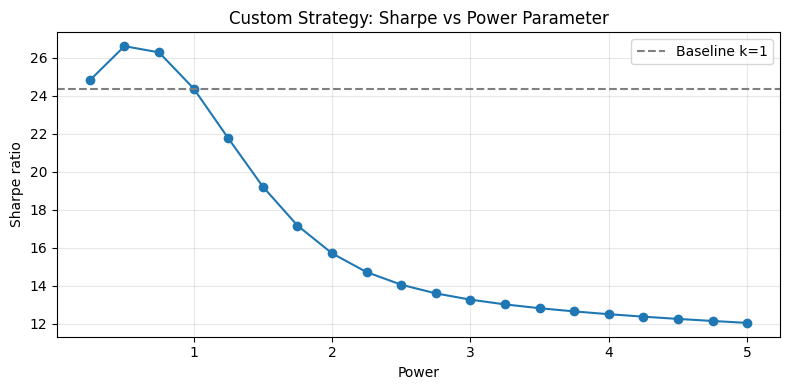

In [86]:
# Custom strategy: power-weighted — further from market => larger weight
# w ∝ -sign(excess) * |excess|^power  (power=1: linear, power=2: quadratic, power=3: cubic)
POWER = 0.5  # Toggle: 1=linear, 2=quadratic, 3=cubic — higher = more concentration on extremes

def custom_strategy_weights(excess, power=POWER):
    """
    Raw weight ∝ -sign(excess) * |excess|^power. Preserves direction (long losers, short winners)
    but scales magnitude: larger |excess| => larger position.
    """
    ex = excess.fillna(0)
    raw = -np.sign(ex) * (np.abs(ex) ** power)
    return normalize_weights_long_short(raw)

# Loop over days with lag-1 excess; use full ret_wide for shift(1) history, iterate over simulation period
excess_lag1 = ret_wide.sub(ret_wide.mean(axis=1), axis=0).shift(1)
custom_weights_list = []
for t in ret_insample.index:
    ex = excess_lag1.loc[t]
    w = custom_strategy_weights(ex, power=POWER)
    custom_weights_list.append(w)
weights_custom = pd.DataFrame(custom_weights_list, index=ret_insample.index, columns=ret_insample.columns)
# Weights already use R(t-1) via excess_lag1; no shift—π(t) = Σ w(t) * R(t) where w(t) ∝ -(R(t-1)-R(t-1))
pi_custom = (weights_custom * ret_insample).sum(axis=1).dropna()
mu_c, vol_c, sh_c = annualize_stats(pi_custom)
print("Custom (power={}): Mean {:.2%}  Vol {:.2%}  Sharpe {:.2f}".format(POWER, mu_c, vol_c, sh_c))
print("Baseline (k=1):   Mean {:.2%}  Vol {:.2%}  Sharpe {:.2f}".format(mu_pi, vol_pi, sharpe_pi))

# Grid search over power
POWER_GRID = np.linspace(0, 5, 21)[1:]  # Toggle: e.g. [1, 1.5, 2, 2.5, 3] or np.arange(1, 4.5, 0.5)
grid_results = []
for p in POWER_GRID:
    w_p = pd.DataFrame([custom_strategy_weights(excess_lag1.loc[t], power=p) for t in ret_insample.index],
                       index=ret_insample.index, columns=ret_insample.columns)
    pi_p = (w_p * ret_insample).sum(axis=1).dropna()  # no shift—weights already lag-1
    mu, vol, sh = annualize_stats(pi_p)
    grid_results.append({'power': round(p, 2), 'Mean': mu, 'Vol': vol, 'Sharpe': sh})
df_grid = pd.DataFrame(grid_results)
best_idx = df_grid['Sharpe'].idxmax()
best_power = df_grid.loc[best_idx, 'power']
print("\nGrid search (power):")
print(df_grid.to_string(index=False))
print("\nBest power = {:.2f} (Sharpe {:.2f})".format(best_power, df_grid.loc[best_idx, 'Sharpe']))

# Plot Sharpe vs power
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(df_grid['power'], df_grid['Sharpe'], 'o-')
ax.axhline(sharpe_pi, color='gray', linestyle='--', label='Baseline k=1')
ax.set_xlabel('Power')
ax.set_ylabel('Sharpe ratio')
ax.set_title('Custom Strategy: Sharpe vs Power Parameter')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## Part 4: Out-of-Sample Analysis

Test periods: 1998-2000, 2001-2003. Requires extended data (1998-2003).

In [87]:
# OOS evaluation: apply same strategy rules (no retraining) to 1998-2000 and 2001-2003.
# Compare all strategies in one table. Custom strategy uses power=0.5.

# Baseline (k=1): compute weights over full ret_wide
w_k1_full = weights_for_lag_k(ret_wide, 1)
pi_full_baseline = compute_portfolio_returns(ret_wide, w_k1_full)

pi_insample_baseline = pi_full_baseline.loc[(pi_full_baseline.index >= SIM_START) & (pi_full_baseline.index <= SIM_END)]
pi_oos1_baseline = pi_full_baseline.loc[(pi_full_baseline.index >= OOS1_START) & (pi_full_baseline.index <= OOS1_END)]
pi_oos2_baseline = pi_full_baseline.loc[(pi_full_baseline.index >= OOS2_START) & (pi_full_baseline.index <= OOS2_END)]

# Custom strategy: power=0.5 (fixed)
CUSTOM_POWER = 0.5
excess_lag1_full = ret_wide.sub(ret_wide.mean(axis=1), axis=0).shift(1).fillna(0)
custom_weights_full = pd.DataFrame(
    [custom_strategy_weights(excess_lag1_full.loc[t], power=CUSTOM_POWER) for t in ret_wide.index],
    index=ret_wide.index, columns=ret_wide.columns
)
pi_full_custom = (custom_weights_full * ret_wide).sum(axis=1).dropna()

pi_insample_custom = pi_full_custom.loc[(pi_full_custom.index >= SIM_START) & (pi_full_custom.index <= SIM_END)]
pi_oos1_custom = pi_full_custom.loc[(pi_full_custom.index >= OOS1_START) & (pi_full_custom.index <= OOS1_END)]
pi_oos2_custom = pi_full_custom.loc[(pi_full_custom.index >= OOS2_START) & (pi_full_custom.index <= OOS2_END)]

# Market returns for context
R_insample = compute_market_return(ret_wide.loc[pi_insample_baseline.index]).reindex(pi_insample_baseline.index).dropna()
R_oos1 = compute_market_return(ret_wide.loc[pi_oos1_baseline.index]).reindex(pi_oos1_baseline.index).dropna()
R_oos2 = compute_market_return(ret_wide.loc[pi_oos2_baseline.index]).reindex(pi_oos2_baseline.index).dropna()

def stats_row(pi_ser):
    mu, vol, sh = annualize_stats(pi_ser)
    return {'Mean': mu, 'Vol': vol, 'Sharpe': sh}

# One table: all strategies × all periods
rows = []
for strategy_name, pi_ins, pi_o1, pi_o2 in [
    ('Baseline (k=1)', pi_insample_baseline, pi_oos1_baseline, pi_oos2_baseline),
    ('Custom (p=0.5)', pi_insample_custom, pi_oos1_custom, pi_oos2_custom),
    ('Market', R_insample, R_oos1, R_oos2),
]:
    rows.append({
        'Strategy': strategy_name,
        'In-sample Mean': stats_row(pi_ins)['Mean'],
        'In-sample Vol': stats_row(pi_ins)['Vol'],
        'In-sample Sharpe': stats_row(pi_ins)['Sharpe'],
        'OOS1 (1998-2000) Mean': stats_row(pi_o1)['Mean'],
        'OOS1 (1998-2000) Vol': stats_row(pi_o1)['Vol'],
        'OOS1 (1998-2000) Sharpe': stats_row(pi_o1)['Sharpe'],
        'OOS2 (2001-2003) Mean': stats_row(pi_o2)['Mean'],
        'OOS2 (2001-2003) Vol': stats_row(pi_o2)['Vol'],
        'OOS2 (2001-2003) Sharpe': stats_row(pi_o2)['Sharpe'],
    })

df_oos = pd.DataFrame(rows)
display(df_oos.style.format({
    'In-sample Mean': '{:.2%}', 'In-sample Vol': '{:.2%}', 'In-sample Sharpe': '{:.2f}',
    'OOS1 (1998-2000) Mean': '{:.2%}', 'OOS1 (1998-2000) Vol': '{:.2%}', 'OOS1 (1998-2000) Sharpe': '{:.2f}',
    'OOS2 (2001-2003) Mean': '{:.2%}', 'OOS2 (2001-2003) Vol': '{:.2%}', 'OOS2 (2001-2003) Sharpe': '{:.2f}',
}))

,Strategy,In-sample Mean,In-sample Vol,In-sample Sharpe,OOS1 (1998-2000) Mean,OOS1 (1998-2000) Vol,OOS1 (1998-2000) Sharpe,OOS2 (2001-2003) Mean,OOS2 (2001-2003) Vol,OOS2 (2001-2003) Sharpe
0,Baseline (k=1),372.64%,15.28%,24.39,193.99%,17.43%,11.13,175.75%,20.58%,8.54
1,Custom (p=0.5),202.46%,7.61%,26.62,106.06%,11.06%,9.59,96.56%,11.38%,8.49
2,Market,14.77%,7.80%,1.89,-3.21%,13.10%,-0.24,6.09%,16.74%,0.36


**Does the 1992-1997 backtest predict OOS results?** Compare the In-sample Sharpe and mean return to OOS1 and OOS2. If OOS Sharpe drops substantially or turns negative, the strategy may have been overfit to the in-sample period. Consistency across OOS1 and OOS2 suggests more robust performance.

### $1M allocation (2004): strategies vs cash — rationale

In [81]:
# Summary: In-sample and OOS performance (Mean %, Vol %, Sharpe)
# Use OOS results to avoid overfitting; favor strategy with best OOS Sharpe across both periods.
sh_oos1_b, sh_oos2_b = annualize_stats(pi_oos1_baseline)[2], annualize_stats(pi_oos2_baseline)[2]
sh_oos1_c, sh_oos2_c = annualize_stats(pi_oos1_custom)[2], annualize_stats(pi_oos2_custom)[2]
avg_sh_baseline = (sh_oos1_b + sh_oos2_b) / 2 if not (np.isnan(sh_oos1_b) or np.isnan(sh_oos2_b)) else 0
avg_sh_custom = (sh_oos1_c + sh_oos2_c) / 2 if not (np.isnan(sh_oos1_c) or np.isnan(sh_oos2_c)) else 0

# Simple heuristic: allocate to best OOS strategy, remainder to cash (risk management)
best_oos_sh = max(avg_sh_baseline, avg_sh_custom, 0)
if best_oos_sh <= 0:
    allocation = {'baseline': 0.0, 'custom': 0.0, 'cash': 1.0}
elif avg_sh_custom >= avg_sh_baseline:
    allocation = {'baseline': 0.0, 'custom': 0.5, 'cash': 0.5}
else:
    allocation = {'baseline': 0.5, 'custom': 0.0, 'cash': 0.5}

print("Proposed $1M allocation (2004):", allocation)
print("Rationale: Allocate to strategy with superior OOS Sharpe; hold 50% cash to limit drawdown risk.")

Proposed $1M allocation (2004): {'baseline': 0.5, 'custom': 0.0, 'cash': 0.5}
Rationale: Allocate to strategy with superior OOS Sharpe; hold 50% cash to limit drawdown risk.
